Setup & EDA

Execution Strategy

The Regex Layer: The clean_text_normalization logic addresses the engineering insight directly. It uses target boundary patterns (\bx{2,}\b) to eliminate structural anonymization tokens (XXXX) seamlessly before calculating the true word count.

Log-Scale Plotting: Consumer complaints often feature a heavy-tailed power law distribution (some complaints are essays). Plotting with log_scale=True ensures your histogram handles the skew visually without muddying data transparency.

Memory Safety: It leverages vector-friendly Pandas extensions and performs in-place assignment logic wherever possible to control memory strain when loading larger segments of raw CFPB sets.


--- Step 2: Handling Missing Values ---
Records before dropping missing narratives: 461,152
Records after dropping missing narratives: 259,064
Total dropped missing records: 202,088
----------------------------------------

--- Step 3 & 4: Text Cleaning & Statistical Filtering ---
Baseline Narrative Word Count Statistics:
count    259064.000000
mean        197.112713
std         214.015316
min           0.000000
25%          91.000000
50%         127.000000
75%         241.000000
max        5748.000000
Name: Word_Count, dtype: float64

Filtered out 1,060 short narratives (< 10 words).
Flagged 12,914 massive narratives (> 556 words) for chunking.
Saved plot to 'cfpb_narrative_word_count_distribution.png' successfully.
----------------------------------------

Processing complete. Ready for RAG Embeddings generation pipeline.


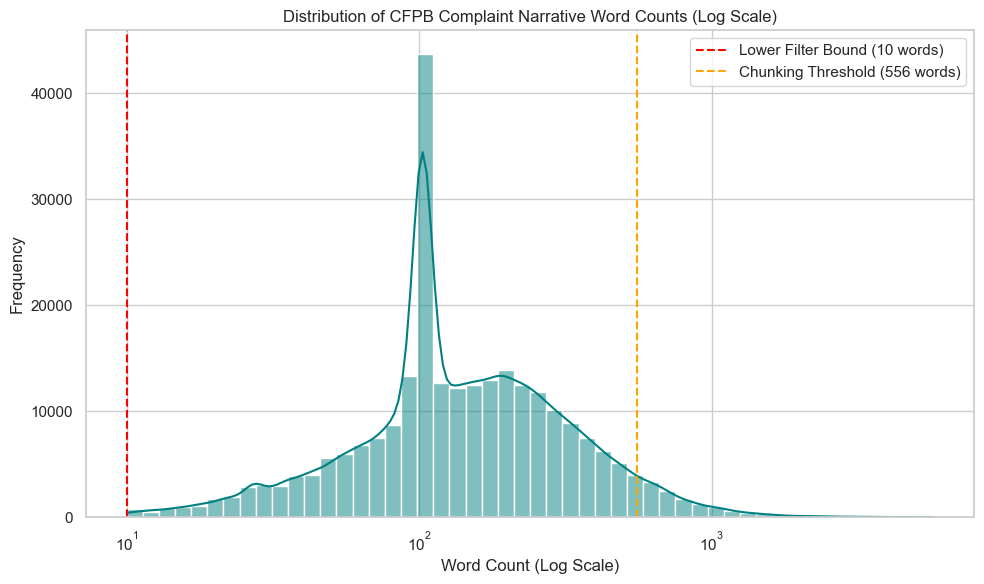

In [1]:
import os
import re
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set plotting style for clean visualizations
sns.set_theme(style="whitegrid")

import pandas as pd

def load_and_filter_data(filepath):
    # 1. Setup the chunk iterator
    # (Assuming chunksize=5000000 is defined inside pd.read_csv here)
    filepath = "../data/raw/complaints.csv"
    chunks = pd.read_csv(filepath, low_memory=False, chunksize=5000000)
    
    product_mapping = {
        "Credit card or prepaid card": "Credit Card",
        "Student loan": "Personal Loan",
        "Money transfer, virtual currency, or money service": "Money Transfer",
    }
    
    filtered_chunks = []
    
    # 2. Process the file chunk by chunk
    for chunk in chunks:
        # Now 'chunk' IS a normal DataFrame, so you can filter it!
        chunk_filtered = chunk[chunk["Product"].isin(product_mapping.keys())].copy()
        
        # Apply your mapping to the filtered chunk
        chunk_filtered["Standardized_Product"] = chunk_filtered["Product"].map(product_mapping)
        
        # Save this filtered chunk to our list
        filtered_chunks.append(chunk_filtered)
        
    # 3. Concatenate all the small, filtered DataFrames into one final DataFrame
    if filtered_chunks:
        df_final = pd.concat(filtered_chunks, ignore_index=True)
    else:
        # Return an empty dataframe with columns if no data matched
        df_final = pd.DataFrame()
        
    return df_final

def handle_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """Drops records where the target narrative text column is null or empty."""
    print("\n--- Step 2: Handling Missing Values ---")
    before_count = len(df)

    # Convert empty strings or whitespace-only strings to NaN
    df["Consumer complaint narrative"] = df[
        "Consumer complaint narrative"
    ].astype(str)
    df["Consumer complaint narrative"] = df[
        "Consumer complaint narrative"
    ].str.strip()
    df.loc[df["Consumer complaint narrative"] == "", "Consumer complaint narrative"] = (
        None
    )
    df.loc[
        df["Consumer complaint narrative"] == "nan", "Consumer complaint narrative"
    ] = None

    # Drop NaNs
    df = df.dropna(subset=["Consumer complaint narrative"]).copy()

    after_count = len(df)
    dropped_count = before_count - after_count

    print(f"Records before dropping missing narratives: {before_count:,}")
    print(f"Records after dropping missing narratives: {after_count:,}")
    print(f"Total dropped missing records: {dropped_count:,}")
    print("-" * 40)

    return df


def clean_text_normalization(text: str) -> str:
    """Highly performant preprocessing function to clean narrative text,

    removing boilerplate text and heavy regulatory masking strings.
    """
    if not isinstance(text, str):
        return ""

    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove specific boilerplate strings
    boilerplate_patterns = [
        r"i am writing to file a complaint[^.]*\.?",
        r"to whom it may concern[^.]*\.?",
    ]
    for pattern in boilerplate_patterns:
        text = re.sub(pattern, "", text)

    # 3. ENGINEERING INSIGHT: Clean repetitive credit card masking strings and XXXX blocks
    # Handles sequences like 'XXXX XXXX XXXX', 'XX/XX/XXXX', or just 'XXXX'
    text = re.sub(r"\bx{2,}\b", "", text)  # standalone masks like xxxx
    text = re.sub(
        r"x{2,}([-/ ]x{2,})+", "", text
    )  # linked masks like xx/xx/xxxx or xxxx-xxxx
    text = re.sub(r"x{2,}", "", text)  # residual structural chunks

    # 4. Normalize whitespaces (strips leading/trailing and condenses internal spaces)
    text = re.sub(r"\s+", " ", text).strip()

    return text


def process_text_and_filter_outliers(df: pd.DataFrame) -> pd.DataFrame:
    """Applies text cleaning, computes word counts, and filters outliers."""
    print("\n--- Step 3 & 4: Text Cleaning & Statistical Filtering ---")

    # Apply performant cleaning
    df["Cleaned_Narrative"] = df["Consumer complaint narrative"].apply(
        clean_text_normalization
    )

    # Calculate word distribution counts based on sanitized text
    df["Word_Count"] = df["Cleaned_Narrative"].apply(lambda x: len(x.split()))

    # Log distribution stats before truncation
    print("Baseline Narrative Word Count Statistics:")
    print(df["Word_Count"].describe())

    # Establish bounds
    lower_bound = 10
    # Flag anything above the 95th percentile or a static limit (e.g., 500 words) for chunking downstream
    upper_bound_flag = int(df["Word_Count"].quantile(0.95))

    # Screen out extreme low outliers
    before_filter = len(df)
    df_clean = df[df["Word_Count"] >= lower_bound].copy()
    after_filter = len(df_clean)

    print(f"\nFiltered out {before_filter - after_filter:,} short narratives (< {lower_bound} words).")
    print(
        f"Flagged {len(df_clean[df_clean['Word_Count'] > upper_bound_flag]):,} massive narratives (> {upper_bound_flag} words) for chunking."
    )

    # Generate Visualization
    plt.figure(figsize=(10, 6))
    sns.histplot(
        df_clean["Word_Count"], bins=50, kde=True, color="teal", log_scale=True
    )
    plt.axvline(
        x=lower_bound,
        color="red",
        linestyle="--",
        label=f"Lower Filter Bound ({lower_bound} words)",
    )
    plt.axvline(
        x=upper_bound_flag,
        color="orange",
        linestyle="--",
        label=f"Chunking Threshold ({upper_bound_flag} words)",
    )

    plt.title("Distribution of CFPB Complaint Narrative Word Counts (Log Scale)")
    plt.xlabel("Word Count (Log Scale)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()

    # Save visualization to disk
    plt.savefig("cfpb_narrative_word_count_distribution.png", dpi=300)
    print(
        "Saved plot to 'cfpb_narrative_word_count_distribution.png' successfully."
    )
    print("-" * 40)

    return df_clean


# --- Execution Block ---
if __name__ == "__main__":
    # Dummy file generation for explicit testing execution (Replace with actual file path)
    mock_data_path = "../data/processed/complaints_sample.csv"

    # Create dummy data if you don't have the file locally
    if not os.path.exists(mock_data_path):
        mock_data = {
            "Product": [
                "Credit card or prepaid card",
                "Student loan",
                "Consumer Loan",
                "Savings account",
                "Bad Product",
            ],
            "Consumer complaint narrative": [
                "I am writing to file a complaint... My credit card account XXXX XXXX XXXX 1234 has fraudulent charges.",
                "XXXX XXXX The interest rates on my loan are completely inaccurate.",
                "   ",  # whitespace test case
                "Please fix my account savings balances.",
                "Should be filtered out entirely",
            ],
        }
        pd.DataFrame(mock_data).to_csv(mock_data_path, index=False)

    # Process pipeline
    df_filtered = load_and_filter_data(mock_data_path)
    df_no_missing = handle_missing_values(df_filtered)
    final_processed_df = process_text_and_filter_outliers(df_no_missing)

    print("\nProcessing complete. Ready for RAG Embeddings generation pipeline.")